In [1]:
import rebound
import numpy as np 
import matplotlib.pyplot as plt

# Test parametri di rebound


Vediamo di fare un setup semplice, gas in box periodiche (+ non periodiche?) e di vedere come cambia 

[Link prova](#sezione2)

<a id='sezione2'></a>
# LA sezione due

In [2]:

boxL = 10
sim = rebound.Simulation()
nx, ny = 10, 5
sim.widget(port=1261,size=(1000,1000))
sim.configure_box(boxL,nx,ny)
sim.boundary = "open"
sim.gravity = "tree"
sim.integrator = "leapfrog"
sim.softening = 0.1
sim.opening_angle2 = 1.5
np.random.seed(0)
M = 10
N = 500
m = 100
T = 50
# più cresce M, o N, o Vx, o diminuisce mBH o vBH
# ovvero più il momento è dominato da quello della particelle
# più rispetto al centro di massa si muove veloce BH
# quindi più stelle sono più lente di lui ovvero rho(<vs)
Vx = 15
nrows = 20
ncols = int(N/nrows)
k = 0
xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
# for x in xs:
#     for y in ys:
#         vx = -2*Vx
#         sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/200)
sim.add(m=m,x=boxL*(nx-1)/nx,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
sim.collision = "none"
steps = int(1e4)
# v = np.zeros(steps)
# theta = np.zeros(steps)
v = []
defs = []
theta = 0
i = 0
k = 0
Nparticles = sim.N
cycle = 0
particle_hash = 0
bs = []

# dt = sim.dt
def heartbeat(sim_pointer):
    global v, theta, i, Nparticles, k, cycle, defs, particle_hash,bs
    sim = sim_pointer.contents
    t = sim.t
    dt = boxL**3/(N-1)/(2*Vx)
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/100,hash=particle_hash)
            bs = np.r_[bs, j]
            particle_hash += 1
        t = 0

        Nparticles = sim.N
    
    v = np.append(v,sim.particles["BH"].vx)
    i+=1

sim.heartbeat = heartbeat

sim.integrator = "leapfrog"

REBOUND Webserver listening on http://localhost:1261 ...


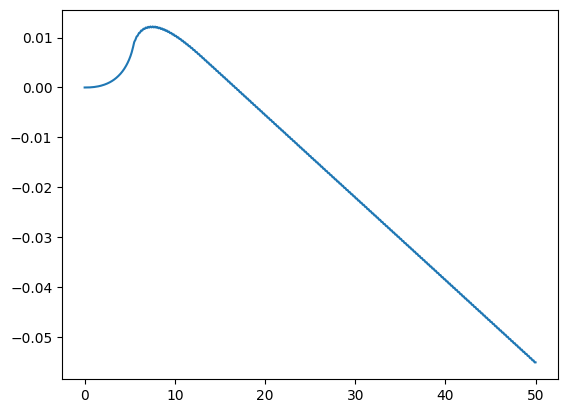

In [3]:
fig, ax = plt.subplots()

sim.integrate(T)
# sim.steps(steps)

ts = np.linspace(0,T,len(v))
ax.plot(ts,v)
plt.show()
# fig.savefig(f"N{N}m{m}t{T}.png")


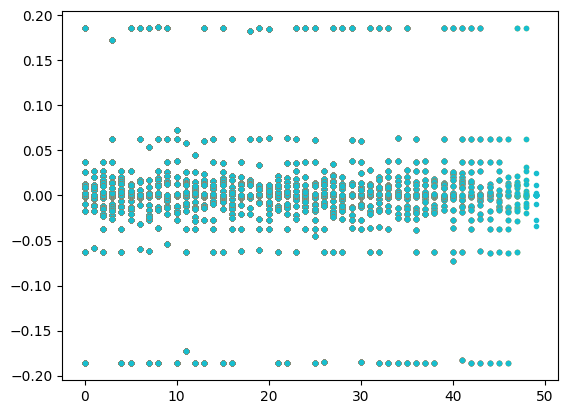

[-298.39231787 -266.02579805 -235.1268705  -198.36257258 -163.11575085
 -126.94739649  -90.73911611  -54.2077928   -18.26552696   18.26984594
   54.21656778   90.72225935  126.94730831  163.11537791  198.36238839
  235.12678401  266.0265431   298.39205146  302.47579466]


/tmp/ipykernel_1516737/2256548188.py:14: RuntimeWarning: divide by zero encountered in divide
  b_over_b90 = 1/np.tan(means/2)


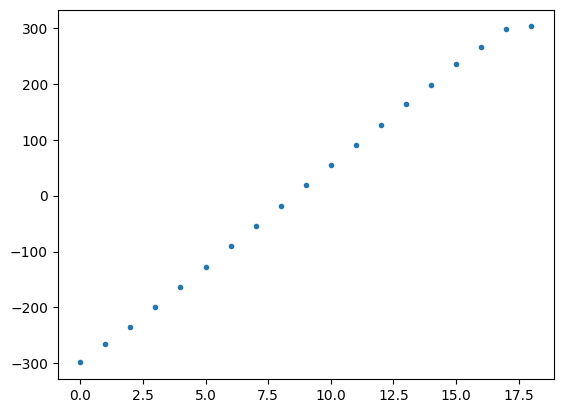

v = 15: m = 35.11440194690892


In [4]:
means = np.zeros(nrows)
fig, ax = plt.subplots()
for b in range(1,nrows):
    defs = []
    for p in sim.particles:
        if p.hash.value != 1753590236 and bs[p.hash.value]==b:
            # if p.x<0.1*nx*boxL and (True or p.x < -0.99*nx*boxL/2 or np.abs(p.y) > 0.99*ny*boxL/2):
            deflection = np.arctan2(p.vy,p.vx)
            deflection = (np.abs(deflection)-np.pi)*np.sign(deflection)
            defs = np.r_[defs, deflection]
            ax.plot(defs,'.',label=f"{b}")
    means[b] = np.mean(defs)
plt.show()
b_over_b90 = 1/np.tan(means/2)
b_over_b90 = b_over_b90[1:]
Xfit = np.arange(nrows)[1:]
print(b_over_b90)
fig, ax = plt.subplots()
# ax.plot(means,'.')
ax.plot(b_over_b90,'.')
# ax.hist(np.tan(defs/2),bins=10000)
# # ax.plot(np.log(-np.tan(defs)),'.',markersize=0.1)
plt.show()

from scipy.optimize import curve_fit

popt, _ = curve_fit(lambda x, m, q: m*x + q, Xfit, b_over_b90)

print(f"v = {Vx}: m = {popt[0]}")


In [5]:
m5 = 3.8468458761804656
m10 = 15.423398930537578
m15 = 35.403351715682646

# Preventivo

FRIZIONE DINAMICAAAA

Test:
- prima di cominciare il test mettere in condizione stazionaria
1. conf semplice
2. conf. con "rotazione differenziale"
3. (opzionale) BH che precipita al centro di un disco

variando:
- massa BH
- velocità relativa (testare stelle v=cost, v=Maxwell-Boltzmann)
- densità stelle

Formula di Chandrasekhar funziona in sistema di rif. dove la velocità media delle particelle è 0, aka isotropa, cioè quello che muove a destra di vx0

dipendenza temporale:
- la forza dovrebbe cambiare esattamente quando vBH ~ sigma (se stelle hanno vx MB)
Per ogni test:
- Tracciare posizione, velocità, accelerazioni BH
- Tracciare distribuzione spazio delle fasi delle particelle (y,vx,vy,v)

Roba computazionale:
- studiare complessità del problema al variare dei parametri della simulazione e funzionalità di rebound


In [29]:

boxL = 10
sim = rebound.Simulation()
nx, ny = 10, 5
sim.widget(port=1264,size=(1000,1000))
sim.configure_box(boxL,nx,ny)
sim.boundary = "open"
sim.gravity = "tree"
sim.integrator = "leapfrog"
sim.softening = 0.1
# sim.opening_angle2 = 1.5
np.random.seed(0)
M = 10
N = 500
m = 100
T = 20
# più cresce M, o N, o Vx, o diminuisce mBH o vBH
# ovvero più il momento è dominato da quello della particelle
# più rispetto al centro di massa si muove veloce BH
# quindi più stelle sono più lente di lui ovvero rho(<vs)
Vx = 2.5
nrows = 20
ncols = int(N/nrows)
k = 0
xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
for x in xs:
    for y in ys:
        vx = -2*Vx
        sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
sim.add(m=m,x=boxL*(nx-1)/nx,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
sim.collision = "none"
steps = int(1e4)
# v = np.zeros(steps)
# theta = np.zeros(steps)
v = []
defs = []
theta = 0
i = 0
k = 0
Nparticles = sim.N
cycle = 0
particle_hash = 0
bs = []

# dt = sim.dt
def heartbeat(sim_pointer):
    global v, theta, i, Nparticles, k, cycle, defs, particle_hash,bs
    sim = sim_pointer.contents
    t = sim.t
    # dt = boxL**3/(N-1)/(2*Vx)
    dt = boxL*nx/ncols/(2*Vx)
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50,hash=particle_hash)
            bs = np.r_[bs, j]
            particle_hash += 1
        t = 0

        Nparticles = sim.N
    
    v = np.append(v,sim.particles["BH"].vx)
    i+=1

sim.heartbeat = heartbeat

sim.integrator = "leapfrog"

REBOUND Webserver listening on http://localhost:1264 ...


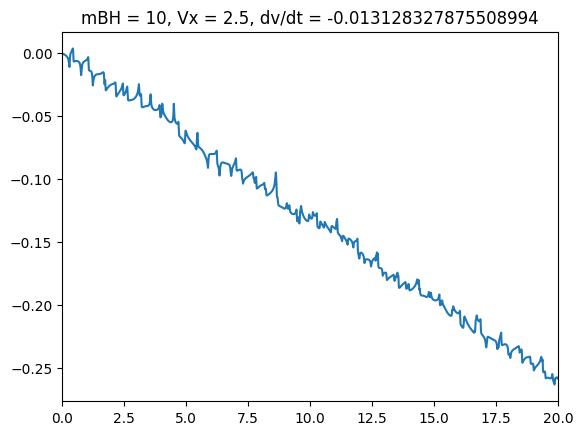

In [ ]:
fig, ax = plt.subplots()

sim.integrate(T)

ts = np.linspace(0,sim.t,len(v))
cut = (ts>0)
popt, _ = curve_fit(lambda x, m, q: m*x + q, ts[cut], v[cut])
m = popt[0]
ax.plot(ts[cut],v[cut])
ax.set_title(f"mBH = {M}, Vx = {Vx}, dv/dt = {m}")
ax.set_xlim(0,20)
plt.show()


M = 10, Vx = 100: dv/dt = -0.00279
M = 10, Vx = 50: dv/dt = -0.00323
M = 10, Vx = 25: dv/dt = -0.00415
M = 10, Vx = 20: dv/dt = -0.00484
M = 10, Vx = 15: dv/dt = -0.00623
M = 10, Vx = 12.5: dv/dt = -0.00772
M = 10, Vx = 10: dv/dt = -0.0102
M = 10, Vx =  5: dv/dt = -0.0227


M = 1, Vx = 100: dv/dt = -0.000263
M = 1, Vx = 50: dv/dt = -0.000327
M = 1, Vx = 25: dv/dt = -0.000413
M = 1, Vx = 20: dv/dt = -0.000480
M = 1, Vx = 15: dv/dt = -0.000633
M = 1, Vx = 12.5: dv/dt = -0.000774
M = 1, Vx = 10: dv/dt = -0.00101
M = 1, Vx =  5: dv/dt = -0.00224

M = 100, Vx = 100: dv/dt = -0.0288

M = 100, Vx = 50: dv/dt = -0.000327
M = 100, Vx = 25: dv/dt = -0.000413
M = 100, Vx = 20: dv/dt = -0.000480
M = 100, Vx = 15: dv/dt = -0.000633
M = 100, Vx = 12.5: dv/dt = -0.000774
M = 100, Vx = 10: dv/dt = -0.00101
M = 100, Vx =  5: dv/dt = -0.00224

# Scan dei parametri

KeyboardInterrupt: 

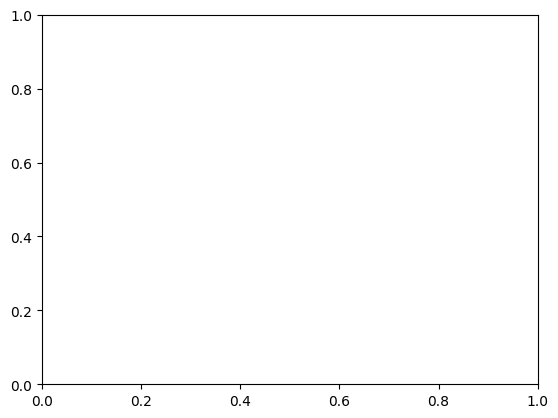

In [ ]:
def heartbeat(sim_pointer):
    global v, theta, i, Nparticles, k, cycle, defs, particle_hash,bs
    sim = sim_pointer.contents
    t = sim.t

    dt = boxL*nx/ncols/(2*Vx) #Particle spawning interval

    #Spawn particles
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50,hash=particle_hash)
            bs = np.r_[bs, j]
            particle_hash += 1
        t = 0
        Nparticles = sim.N

    v = np.append(v,sim.particles["BH"].vx) #save BH velocity
    i+=1

Ms = np.linspace(5,50,10)
ms = np.linspace(5,50,10)
Vxs = np.linspace(5,50,10)

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 500
T = 10
nrows = 20
ncols = int(N/nrows)

out = []

for M in Ms:
    for m in ms:
        for Vx in Vxs:
            sim = rebound.Simulation()
            sim.heartbeat = heartbeat
            # sim.widget(port=1264,size=(1000,1000))
            sim.configure_box(boxL,nx,ny)
            sim.boundary = "open"
            sim.gravity = "tree"
            sim.integrator = "leapfrog"
            sim.softening = 0.1
            sim.opening_angle2 = 1.5
            sim.collision = "none"

            k = 0
            #Add initial particles
            xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
            ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
            for x in xs:
                for y in ys:
                    vx = -2*Vx
                    sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
            sim.add(m=m,x=boxL*(nx-1)/nx,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
            v = []
            defs = []
            theta = 0
            i = 0
            Nparticles = sim.N
            cycle = 0
            particle_hash = 0
            bs = []

            fig, ax = plt.subplots()

            sim.integrate(T)

            ts = np.linspace(0,sim.t,len(v))
            cut = (ts>=0)
            popt, _ = curve_fit(lambda x, a, q: a*x + q, ts[cut], v[cut])
            a = popt[0]
            ax.plot(ts[cut],v[cut])
            ax.set_title(f"mBH = {M}, Vx = {Vx}, dv/dt = {a}")
            filename = f"scan/M{M:.0f}m{m:.0f}Vx{Vx:.0f}.png"
            fig.savefig(filename)
            plt.close()

            results = {
                "M": M,
                "m": m,
                "Vx": Vx,
                "v": v,
                "a": a
            }

            out.append(results)
